#Training and running a linear model usingf scikit_learn

In [1]:
import matplotlib.pyplot as plt 
import numpy as np      
import pandas as pd
import sklearn.linear_model as m

#Load the data

In [10]:
oecd_bli = pd.read_csv("oecd_bli_2015.csv", thousands=',')
gdp_per_capita = pd.read_csv("gdp_per_capita.csv",thousands=',',delimiter='\t',
 encoding='latin1', na_values='n/a')

#prepare the data

In [12]:
def prepare_country_stats(oecd_bli, gdp_per_capita):
    # Filter the OECD data
    oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"]
    oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")
    
    # Prepare the GDP data
    gdp_per_capita.rename(columns={"2015": "GDP per capita"}, inplace=True)
    gdp_per_capita.set_index("Country", inplace=True)
    
    # Merge the two dataframes
    full_country_stats = pd.merge(left=oecd_bli, right=gdp_per_capita,
                                  left_index=True, right_index=True)
    full_country_stats.sort_values(by="GDP per capita", inplace=True)
    
    # Remove some outliers to match the book's example
    remove_indices = [0, 1, 6, 8, 33, 34, 35]
    keep_indices = list(set(range(36)) - set(remove_indices))
    
    return full_country_stats[["GDP per capita", 'Life satisfaction']].iloc[keep_indices]

In [13]:
country_stats = prepare_country_stats(oecd_bli, gdp_per_capita)
X = np.c_[country_stats["GDP per capita"]]
y = np.c_[country_stats["Life satisfaction"]]


#visualize the data

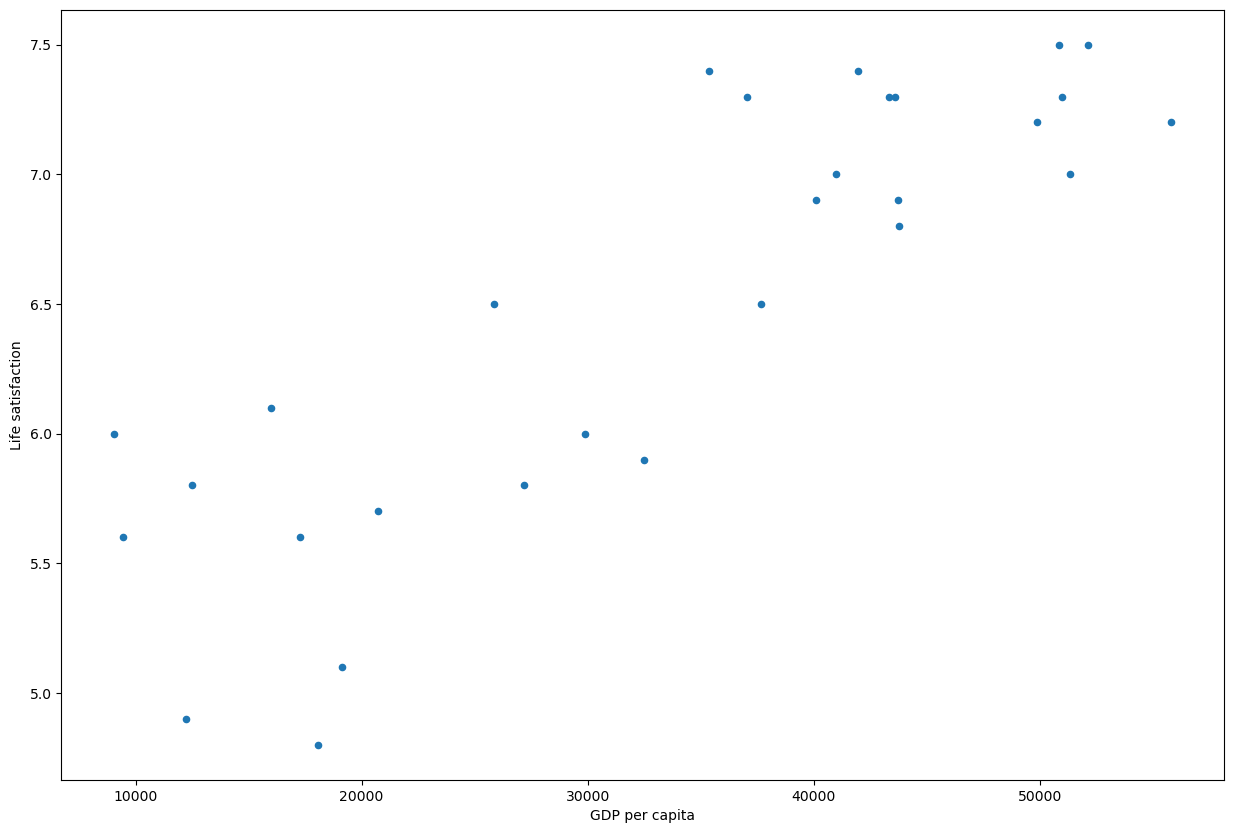

In [14]:
country_stats.plot(kind='scatter', x="GDP per capita", y='Life satisfaction', figsize=(15,10))
plt.show()

#select linear model

In [15]:
model = m.LinearRegression()

#train the model


In [16]:
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Make Prediction for Country

In [19]:
X_new = [[89472]]
print(model.predict(X_new))

[[9.24750998]]


FOR K_CLUSTERRING

In [25]:
import sklearn.neighbors as neigh
model_neigh = neigh.KNeighborsRegressor(n_neighbors=10)
model_neigh.fit(X,y)
X_new = [[89472]]
print(model.predict(X_new))

[[9.24750998]]
